Upload your commercial EIA Excel files (e.g., b19-b30)


Saving b23.xls to b23.xls

Uploaded files:
- b23.xls

Files used:
- b19.xlsx
- b20.xlsx
- b21.xlsx
- b22.xlsx
- b23.xls

Loaded b19.xlsx
Table type: energy_sources
Rows: 105

Loaded b20.xlsx
Table type: energy_sources
Rows: 105

Loaded b21.xlsx
Table type: end_uses
Rows: 109

Loaded b22.xlsx
Table type: energy_sources
Rows: 105

Could not load b23.xls: Could not detect header row in b23.xls

Table type counts:
Table_Type
energy_sources    315
end_uses          109
Name: count, dtype: int64

Energy source subset files:
Source_File
b19.xlsx    105
b20.xlsx    105
b22.xlsx    105
Name: count, dtype: int64

Model data preview:
   Total_NonElectric_Energy  Year_Index  Gas_Share  Oil_Share  Heat_Share  \
0                    4374.0          19   0.679927   0.133288    0.019662   
2                    1723.0          19   0.651770   0.140453    0.000000   
3                     923.0          19   0.735645   0.112676    0.000000   
4                     812.0          19   0.732759   0.131773

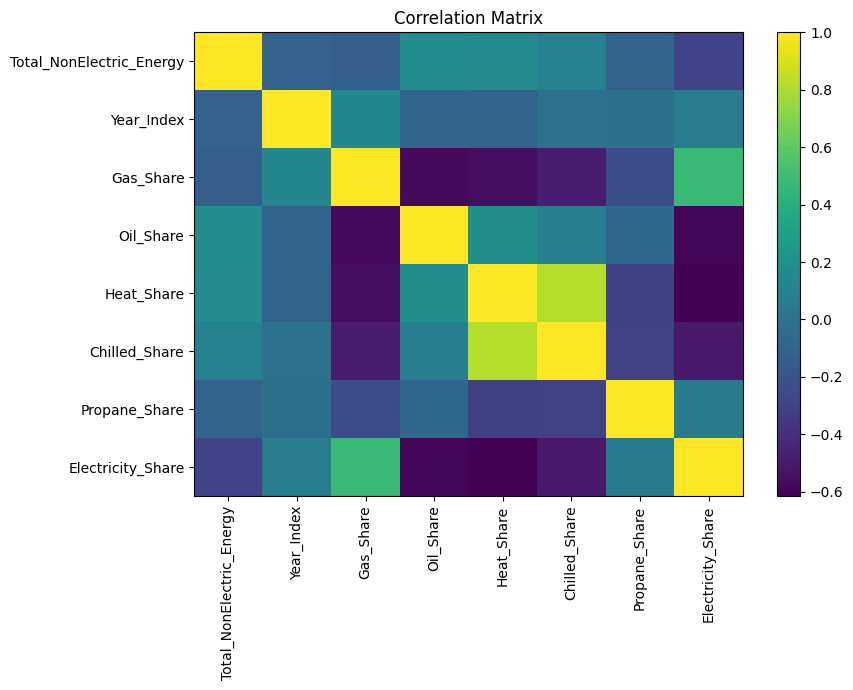


Correlation with Electricity_Share:
Electricity_Share           1.000000
Gas_Share                   0.479786
Year_Index                  0.069739
Propane_Share               0.056504
Total_NonElectric_Energy   -0.292319
Chilled_Share              -0.502512
Oil_Share                  -0.585831
Heat_Share                 -0.614623
Name: Electricity_Share, dtype: float64


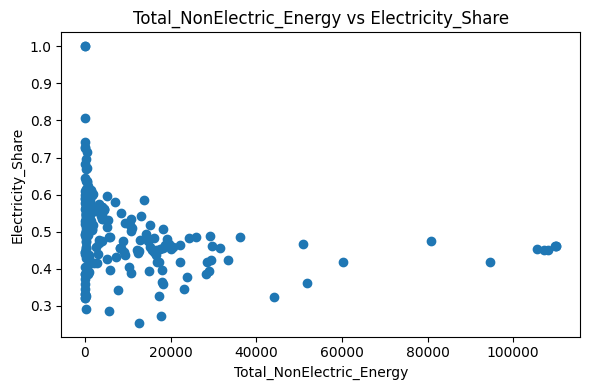

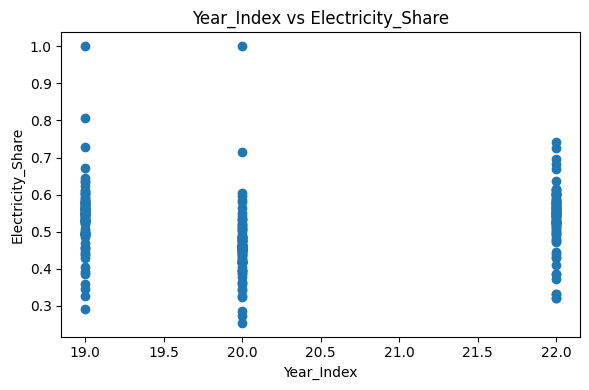

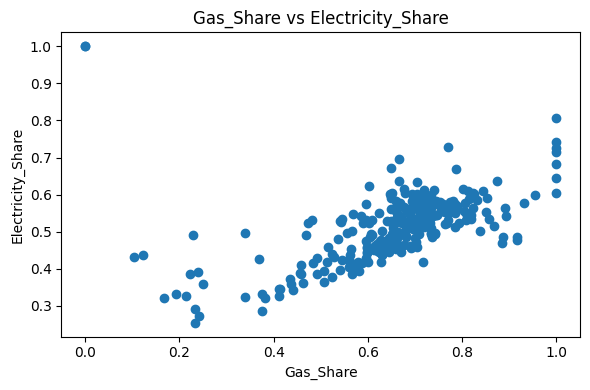

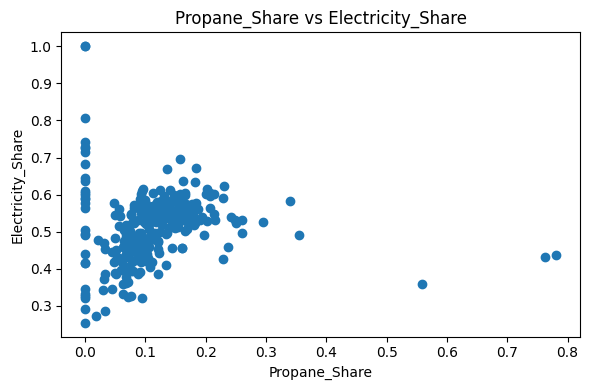


Electricity share relationship model results:
Features used: ['Total_NonElectric_Energy', 'Year_Index', 'Gas_Share', 'Oil_Share', 'Heat_Share', 'Chilled_Share', 'Propane_Share']
Training samples: 228
Testing samples: 57
MSE: 0.03210412397072649
RMSE: 0.17917623718207304
MAE: 0.11494535491644005
R^2: -3.142202777771349


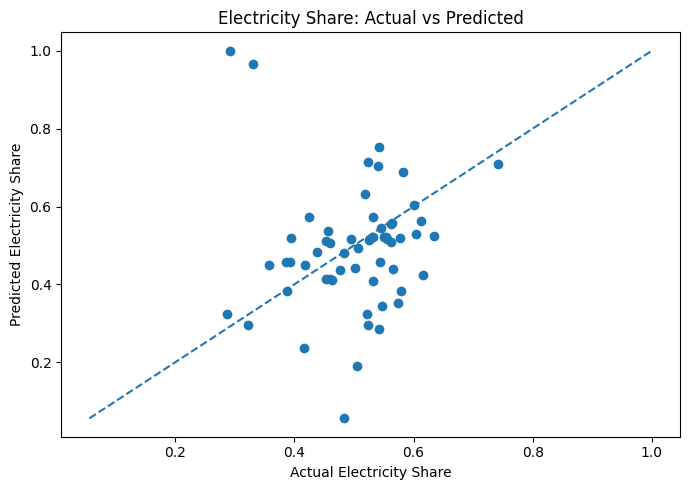


Approximate feature influence:
                    Feature  Approx_Importance
4                Heat_Share           0.346817
5             Chilled_Share           0.324844
2                 Gas_Share           0.305829
0  Total_NonElectric_Energy           0.284154
1                Year_Index           0.259256
6             Propane_Share           0.255712
3                 Oil_Share           0.251299


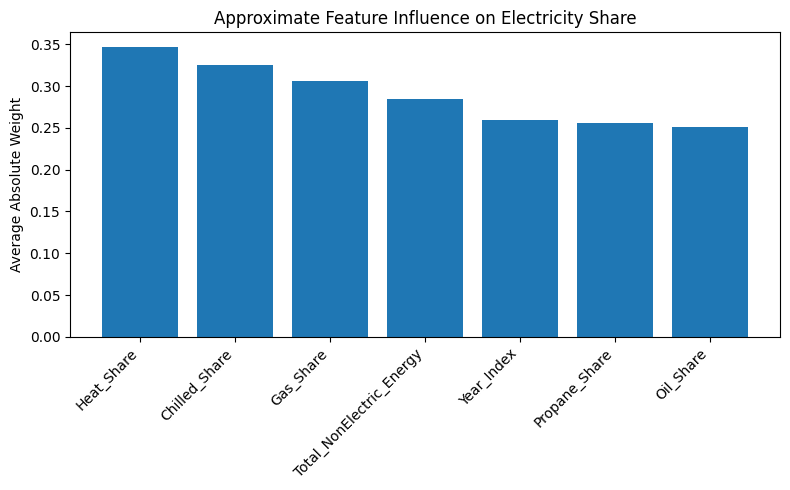

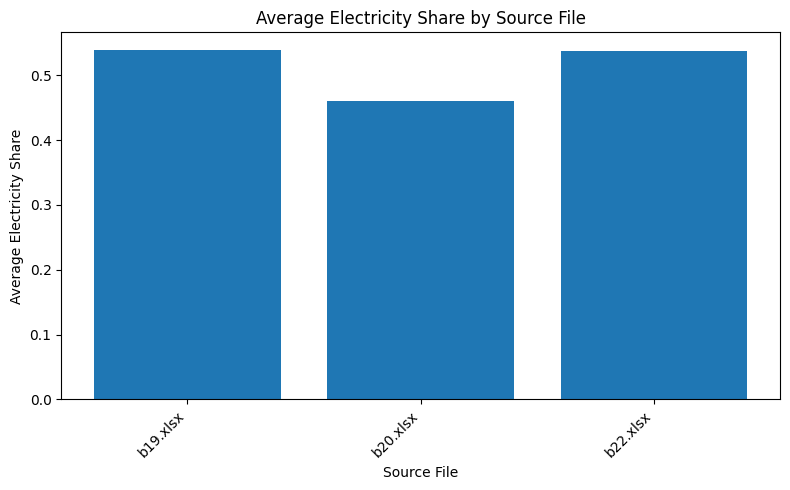


Average energy composition (%):
Electricity               45.60
Natural_Gas               33.06
Fuel_Oil                  10.79
District_Heat              3.33
District_Chilled_Water     2.13
Propane                    5.10
dtype: float64


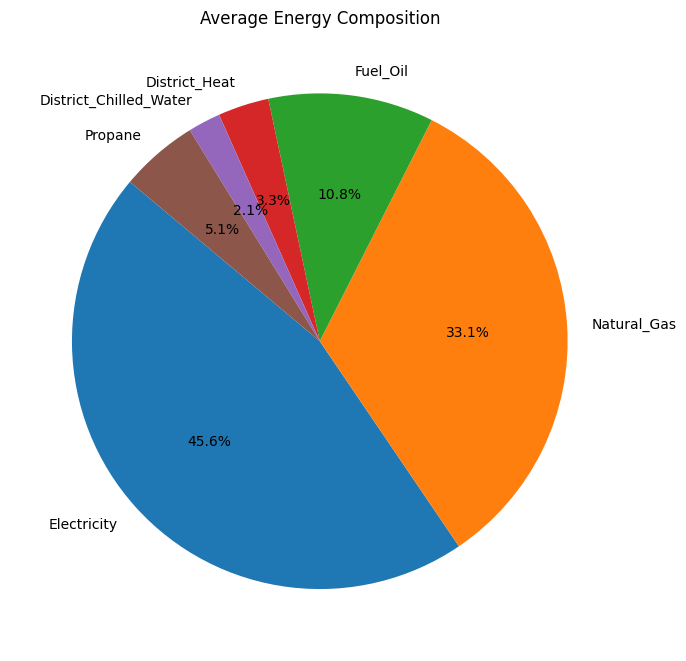


Analysis complete.


In [3]:
# Relationship model for electricity share in commercial buildings

# Imports
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Upload Excel files
print("Upload your commercial EIA Excel files (e.g., b19-b30)")
uploaded = files.upload()

print("\nUploaded files:")
for name in uploaded.keys():
    print("-", name)


# Helper functions for cleaning and parsing EIA tables
def clean_text(x):
    if pd.isna(x):
        return ""
    s = str(x).replace("\n", " ").replace("\r", " ").strip()
    s = re.sub(r"\s+", " ", s)
    return s


def normalize_header_text(x):
    s = clean_text(x).lower()
    replacements = {
        "elec- tricity": "electricity",
        "elec tricity": "electricity",
        "gener- ation": "generation",
        "manu- facturing": "manufacturing",
        "space-heating": "space heating",
        "water-heating": "water heating",
    }
    for old, new in replacements.items():
        s = s.replace(old, new)

    s = s.replace("-", " ")
    s = s.replace("/", " ")
    s = s.replace(",", "")
    s = re.sub(r"\s+", " ", s).strip()
    return s


def is_rse_header(h):
    h = normalize_header_text(h)
    return h == "rse" or "rse" in h or "relative standard error" in h


def detect_table_type(raw_df):
    search_rows = min(8, len(raw_df))
    text_blob = " ".join(
        clean_text(raw_df.iloc[i, 0]) for i in range(search_rows)
        if raw_df.shape[1] > 0
    )
    t = normalize_header_text(text_blob)

    if "energy sources" in t and "space heating" not in t and "primary" not in t:
        return "energy_sources"
    elif "energy end uses" in t:
        return "end_uses"
    elif "space heating energy sources" in t and "primary" not in t:
        return "space_heating_sources"
    elif "primary space heating energy sources" in t:
        return "primary_heating_source"
    else:
        return "unknown"


def standardize_columns(raw_headers):
    standardized = []
    keep_mask = []

    for idx, h in enumerate(raw_headers):
        h_norm = normalize_header_text(h)

        if is_rse_header(h):
            standardized.append(f"DROP_RSE_{idx}")
            keep_mask.append(False)
            continue

        if idx == 0:
            standardized.append("Category")
            keep_mask.append(True)
        elif h_norm == "all buildings":
            standardized.append("All_Buildings")
            keep_mask.append(True)
        elif h_norm == "":
            standardized.append(f"Blank_{idx}")
            keep_mask.append(False)
        elif "electricity generation" in h_norm:
            standardized.append("Electricity_Generation")
            keep_mask.append(True)
        elif h_norm == "electricity":
            standardized.append("Electricity")
            keep_mask.append(True)
        elif "natural gas" in h_norm:
            standardized.append("Natural_Gas")
            keep_mask.append(True)
        elif "fuel oil" in h_norm:
            standardized.append("Fuel_Oil")
            keep_mask.append(True)
        elif "district chilled water" in h_norm or "district chilled" in h_norm:
            standardized.append("District_Chilled_Water")
            keep_mask.append(True)
        elif "district heat" in h_norm:
            standardized.append("District_Heat")
            keep_mask.append(True)
        elif "propane" in h_norm:
            standardized.append("Propane")
            keep_mask.append(True)
        elif "solar" in h_norm:
            standardized.append("Solar")
            keep_mask.append(True)
        elif "wood" in h_norm or "coal" in h_norm:
            standardized.append("Wood_Coal_Other")
            keep_mask.append(True)
        elif h_norm in ["other1", "other 1", "other"]:
            standardized.append("Other")
            keep_mask.append(True)
        else:
            standardized.append(re.sub(r"\W+", "_", h_norm).strip("_").title())
            keep_mask.append(True)

    seen = {}
    unique_cols = []
    for col in standardized:
        if col not in seen:
            seen[col] = 0
            unique_cols.append(col)
        else:
            seen[col] += 1
            unique_cols.append(f"{col}_{seen[col]}")

    return unique_cols, keep_mask


def remove_nondata_rows(df):
    if "Category" not in df.columns:
        return df

    bad_patterns = [
        "rse row factors",
        "rse column factors",
        "row factors",
        "column factors",
        "see notes",
        "more than one may apply",
        "no data",
        "weather sensitive",
        "rows may not sum",
        "percents may not add",
    ]

    category_clean = df["Category"].astype(str).str.lower().str.strip()
    mask = pd.Series(True, index=df.index)

    for pat in bad_patterns:
        mask &= ~category_clean.str.contains(pat, na=False)

    mask &= category_clean.ne("")
    return df[mask].reset_index(drop=True)


def get_preferred_files():
    all_files = glob.glob("b*.xls") + glob.glob("b*.xlsx")
    preferred = {}

    for f in sorted(all_files):
        base = os.path.splitext(os.path.basename(f))[0]
        ext = os.path.splitext(f)[1].lower()
        if base not in preferred:
            preferred[base] = f
        elif ext == ".xlsx":
            preferred[base] = f

    return sorted(preferred.values())


def load_eia_table(filename):
    raw = pd.read_excel(filename, header=None)
    table_type = detect_table_type(raw)

    header_marker_row = None
    for i, row in raw.iterrows():
        row_text = row.astype(str).fillna("").apply(normalize_header_text)
        if (row_text == "all buildings").any():
            header_marker_row = i
            break

    if header_marker_row is None:
        raise ValueError(f"Could not detect header row in {filename}")

    raw_headers = raw.iloc[header_marker_row].tolist()
    columns, keep_mask = standardize_columns(raw_headers)

    data = raw.iloc[header_marker_row + 1:].reset_index(drop=True)
    data.columns = columns

    cols_to_keep = [col for col, keep in zip(data.columns, keep_mask) if keep]
    data = data[cols_to_keep]

    data = remove_nondata_rows(data)

    for col in data.columns:
        if col != "Category":
            data[col] = pd.to_numeric(data[col], errors="coerce")

    data["Source_File"] = os.path.basename(filename)
    data["Table_Type"] = table_type

    match = re.search(r"b(\d+)", os.path.basename(filename).lower())
    data["Year_Index"] = int(match.group(1)) if match else np.nan

    numeric_candidate_cols = [
        c for c in data.columns if c not in ["Category", "Source_File", "Table_Type"]
    ]
    data = data.dropna(subset=numeric_candidate_cols, how="all").reset_index(drop=True)

    return data


# Load and combine tables
files_list = get_preferred_files()

print("\nFiles used:")
for f in files_list:
    print("-", f)

tables = []
for file in files_list:
    try:
        temp = load_eia_table(file)
        tables.append(temp)
        print(f"\nLoaded {file}")
        print("Table type:", temp["Table_Type"].iloc[0] if not temp.empty else "empty")
        print("Rows:", len(temp))
    except Exception as e:
        print(f"\nCould not load {file}: {e}")

if not tables:
    raise ValueError("No usable tables were loaded.")

combined_data = pd.concat(tables, ignore_index=True, sort=False)

print("\nTable type counts:")
print(combined_data["Table_Type"].value_counts(dropna=False))


# Keep only energy source tables
model_subset = combined_data[
    combined_data["Table_Type"] == "energy_sources"
].copy()

if model_subset.empty:
    raise ValueError("No energy source tables found after cleaning.")

print("\nEnergy source subset files:")
print(model_subset["Source_File"].value_counts())


# Build energy features
energy_parts = [
    "Natural_Gas",
    "Fuel_Oil",
    "District_Heat",
    "District_Chilled_Water",
    "Propane"
]

present_energy_parts = [c for c in energy_parts if c in model_subset.columns]
if len(present_energy_parts) == 0:
    raise ValueError("No common energy source columns found.")

for col in present_energy_parts:
    model_subset[col] = model_subset[col].fillna(0)

model_subset["Total_NonElectric_Energy"] = model_subset[present_energy_parts].sum(axis=1)

if "Electricity" not in model_subset.columns:
    raise ValueError("No Electricity column found.")

model_subset = model_subset.dropna(subset=["Electricity", "Year_Index"]).copy()
model_subset = model_subset[model_subset["Electricity"] > 0].copy()

model_subset["Total_Energy_With_Electricity"] = (
    model_subset["Electricity"] + model_subset["Total_NonElectric_Energy"]
)

model_subset = model_subset[
    model_subset["Total_Energy_With_Electricity"] > 0
].copy()

# Target variable: electricity share
model_subset["Electricity_Share"] = (
    model_subset["Electricity"] / model_subset["Total_Energy_With_Electricity"]
)

# Energy composition features
model_subset["Gas_Share"] = np.where(
    model_subset["Total_NonElectric_Energy"] > 0,
    model_subset["Natural_Gas"] / model_subset["Total_NonElectric_Energy"],
    0
)

model_subset["Oil_Share"] = np.where(
    model_subset["Total_NonElectric_Energy"] > 0,
    model_subset["Fuel_Oil"] / model_subset["Total_NonElectric_Energy"],
    0
)

model_subset["Heat_Share"] = np.where(
    model_subset["Total_NonElectric_Energy"] > 0,
    model_subset["District_Heat"] / model_subset["Total_NonElectric_Energy"],
    0
)

model_subset["Chilled_Share"] = np.where(
    model_subset["Total_NonElectric_Energy"] > 0,
    model_subset["District_Chilled_Water"] / model_subset["Total_NonElectric_Energy"],
    0
)

model_subset["Propane_Share"] = np.where(
    model_subset["Total_NonElectric_Energy"] > 0,
    model_subset["Propane"] / model_subset["Total_NonElectric_Energy"],
    0
)


# Select features for the relationship model
candidate_features = [
    "Total_NonElectric_Energy",
    "Year_Index",
    "Gas_Share",
    "Oil_Share",
    "Heat_Share",
    "Chilled_Share",
    "Propane_Share"
]

available_features = [c for c in candidate_features if c in model_subset.columns]

model_data = model_subset[available_features + ["Electricity_Share"]].dropna().copy()

print("\nModel data preview:")
print(model_data.head())
print("\nModel dataset shape:", model_data.shape)

if len(model_data) < 10:
    raise ValueError("Not enough cleaned rows for analysis.")


# Correlation matrix
corr_cols = available_features + ["Electricity_Share"]
corr_matrix = model_data[corr_cols].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("\nCorrelation with Electricity_Share:")
print(corr_matrix["Electricity_Share"].sort_values(ascending=False))


# Scatter plots for key relationships
scatter_features = [
    f for f in ["Total_NonElectric_Energy", "Year_Index", "Gas_Share", "Propane_Share"]
    if f in model_data.columns
]

for f in scatter_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(model_data[f], model_data["Electricity_Share"])
    plt.xlabel(f)
    plt.ylabel("Electricity_Share")
    plt.title(f"{f} vs Electricity_Share")
    plt.tight_layout()
    plt.show()


# Train the neural network relationship model
X = model_data[available_features]
y = model_data["Electricity_Share"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = MLPRegressor(
    hidden_layer_sizes=(12, 6),
    activation="relu",
    solver="adam",
    max_iter=3000,
    random_state=42
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Clamp predictions to valid share range
y_pred = np.clip(y_pred, 0, 1)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nElectricity share relationship model results:")
print("Features used:", available_features)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R^2:", r2)


# Actual vs predicted plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual Electricity Share")
plt.ylabel("Predicted Electricity Share")
plt.title("Electricity Share: Actual vs Predicted")
plt.tight_layout()
plt.show()


# Approximate feature influence from first-layer weights
importance = np.abs(model.coefs_[0]).mean(axis=1)
importance_df = pd.DataFrame({
    "Feature": available_features,
    "Approx_Importance": importance
}).sort_values(by="Approx_Importance", ascending=False)

print("\nApproximate feature influence:")
print(importance_df)

plt.figure(figsize=(8, 5))
plt.bar(importance_df["Feature"], importance_df["Approx_Importance"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Absolute Weight")
plt.title("Approximate Feature Influence on Electricity Share")
plt.tight_layout()
plt.show()


# Average electricity share by file
file_summary = model_subset.groupby("Source_File")["Electricity_Share"].mean().dropna()

if not file_summary.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(file_summary.index.astype(str), file_summary.values)
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Source File")
    plt.ylabel("Average Electricity Share")
    plt.title("Average Electricity Share by Source File")
    plt.tight_layout()
    plt.show()


# Pie chart of average energy composition
energy_cols = [
    "Electricity",
    "Natural_Gas",
    "Fuel_Oil",
    "District_Heat",
    "District_Chilled_Water",
    "Propane"
]

energy_cols_present = [c for c in energy_cols if c in model_subset.columns]

avg_energy = model_subset[energy_cols_present].mean()
energy_percent = avg_energy / avg_energy.sum()

print("\nAverage energy composition (%):")
print((energy_percent * 100).round(2))

plt.figure(figsize=(7, 7))
plt.pie(
    energy_percent,
    labels=energy_percent.index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Average Energy Composition")
plt.tight_layout()
plt.show()

print("\nAnalysis complete.")